---
title: Tek Yönlü ve Çok Yönlü Varyans Analizi (MANOVA) Raporu
author: Muhammed İlyas Saylık
date: 4 Nisan 2026
numbersections: true
lang: tr
geometry: margin=2cm
fontsize: 11pt
linestretch: 1.15
---

**Öğrenci No:** 230106016  
**Ders:** Çok Değişkenli İstatistiksel Analiz  
**Hazırlayan:** Muhammed İlyas Saylık

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from statsmodels.multivariate.manova import MANOVA

In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Değişken Adı            |	Rol	Tip	Tanım|	Birimler|	Eksik Değerler |
------------------------|----------------|------------|----------------|
çanak yaprağı uzunluğu  |	Özellik	Sürekli|	santimetre  |	HAYIR |
------------------------|-------------------|------------|----------------|---------------
çanak yaprağı genişliği |	Özellik	Sürekli	|	santimetre |	HAYIR |
------------------------|--------------------------------------------
taç yaprağı uzunluğu    |	Özellik	Sürekli	 |	santimetre |	HAYIR |
------------------------|------------------------------------------
taç yaprağı genişliği   |	Özellik	Sürekli	 |	santimetre |	HAYIR |
------------------------|-------------------------------------------
sınıf	Hedef	Kategorik	İris bitkisinin sınıfı: Iris Setosa, Iris Versicolour veya Iris Virginica		HAYIR

iris veri seti sınıflandırma problemleri için kullanılan eski bir verisetidir istatistik ve makine öğrenmesinde yaygın olarak kullanılır veri kümesi her biri 50 örnekten oluşan 3 sınıf içerir her sınıf bir bitki türünü ifade etmektedir

In [4]:
data = iris.groupby('species').sample(n=20)
# her grup için rastgele 20 örnek alarak veri setini oluşturdum

In [188]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
41,4.5,2.3,1.3,0.3,setosa
25,5.0,3.0,1.6,0.2,setosa
28,5.2,3.4,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
0,5.1,3.5,1.4,0.2,setosa


In [8]:
normality_results = iris.groupby('species').apply(
    lambda x: pg.multivariate_normality(x.drop(columns='species'))
).apply(pd.Series).reset_index()

# Tabloyu daha okunaklı (SPSS stili) hale getirelim
normality_results.columns = ['Grup (Species)', 'HZ_Istatiği', 'p-değeri', 'Normal_Dağılım']
print(normality_results)

  Grup (Species)  HZ_Istatiği  p-değeri  Normal_Dağılım
0         setosa     0.948845  0.049954           False
1     versicolor     0.838801  0.226199            True
2      virginica     0.757010  0.497024            True


C:\Users\İlyas\AppData\Local\Temp\ipykernel_23388\188231734.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  normality_results = iris.groupby('species').apply(


$H_0$ (Sıfır Hipotezi): İlgili gruba ait veri seti çok değişkenli normal dağılıma sahiptir.

$H_1$ (Alternatif Hipotez): İlgili gruba ait veri seti çok değişkenli normal dağılıma sahip değildir.

Grup (Species),HZ_İstatistiği,p-değeri,Karar (α=0.05)

Setosa,0.9488,0.0499,H0 Reddedilir

Versicolor,0.8388,0.2262,H0 Reddedilemez

Virginica,0.7570,0.4970,H0 Reddedilemez

## Box_m 

Hipotezlerin Kurulması$H_0$ (Sıfır Hipotezi): Grupların varyans-kovaryans matrisleri homojendir ($\Sigma_1 = \Sigma_2 = \dots = \Sigma_k$).

$H_1$ (Alternatif Hipotez): Grupların varyans-kovaryans matrisleri birbirinden anlamlı derecede farklıdır.

In [9]:
# Box's M Testi: Doğru Parametre Kullanımı
# 'species' dışındaki sayısal sütunları (bağımlı değişkenler) ve 'species' sütununu veriyoruz
box_m_results = pg.box_m(data, dvs=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], group='species')

# Sonuçları tablo olarak görüntüleme
print(box_m_results.to_markdown())

|     |    Chi2 |   df |        pval | equal_cov   |
|:----|--------:|-----:|------------:|:------------|
| box | 85.0401 |   20 | 5.38774e-10 | False       |


---

In [10]:
maov = MANOVA.from_formula('sepal_length + sepal_width + petal_length + petal_width ~ species', data=data)

# Sonuçları ekrana basıyoruz
print(maov.mv_test())

                   Multivariate linear model
                                                               
---------------------------------------------------------------
        Intercept         Value  Num DF  Den DF F Value  Pr > F
---------------------------------------------------------------
           Wilks' lambda  0.0163 4.0000 54.0000 814.3275 0.0000
          Pillai's trace  0.9837 4.0000 54.0000 814.3275 0.0000
  Hotelling-Lawley trace 60.3206 4.0000 54.0000 814.3275 0.0000
     Roy's greatest root 60.3206 4.0000 54.0000 814.3275 0.0000
---------------------------------------------------------------
                                                               
---------------------------------------------------------------
        species          Value  Num DF  Den DF  F Value  Pr > F
---------------------------------------------------------------
          Wilks' lambda  0.0268 8.0000 108.0000  68.9135 0.0000
         Pillai's trace  1.1508 8.0000 110.0000  18.6332 0.

In [11]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Her bir bağımlı değişken için ayrı ayrı ANOVA (Univariate)
variables = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for var in variables:
    model = ols(f'{var} ~ species', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    print(f"\n--- {var} için ANOVA Sonuçları ---")
    print(anova_table)


--- sepal_length için ANOVA Sonuçları ---
             sum_sq    df          F        PR(>F)
species   21.758333   2.0  37.483755  4.065587e-11
Residual  16.543500  57.0        NaN           NaN

--- sepal_width için ANOVA Sonuçları ---
          sum_sq    df          F        PR(>F)
species   5.9770   2.0  24.689398  1.892622e-08
Residual  6.8995  57.0        NaN           NaN

--- petal_length için ANOVA Sonuçları ---
              sum_sq    df           F        PR(>F)
species   174.536333   2.0  408.364297  1.633811e-34
Residual   12.181000  57.0         NaN           NaN

--- petal_width için ANOVA Sonuçları ---
             sum_sq    df           F        PR(>F)
species   29.242333   2.0  353.213181  7.648382e-33
Residual   2.359500  57.0         NaN           NaN


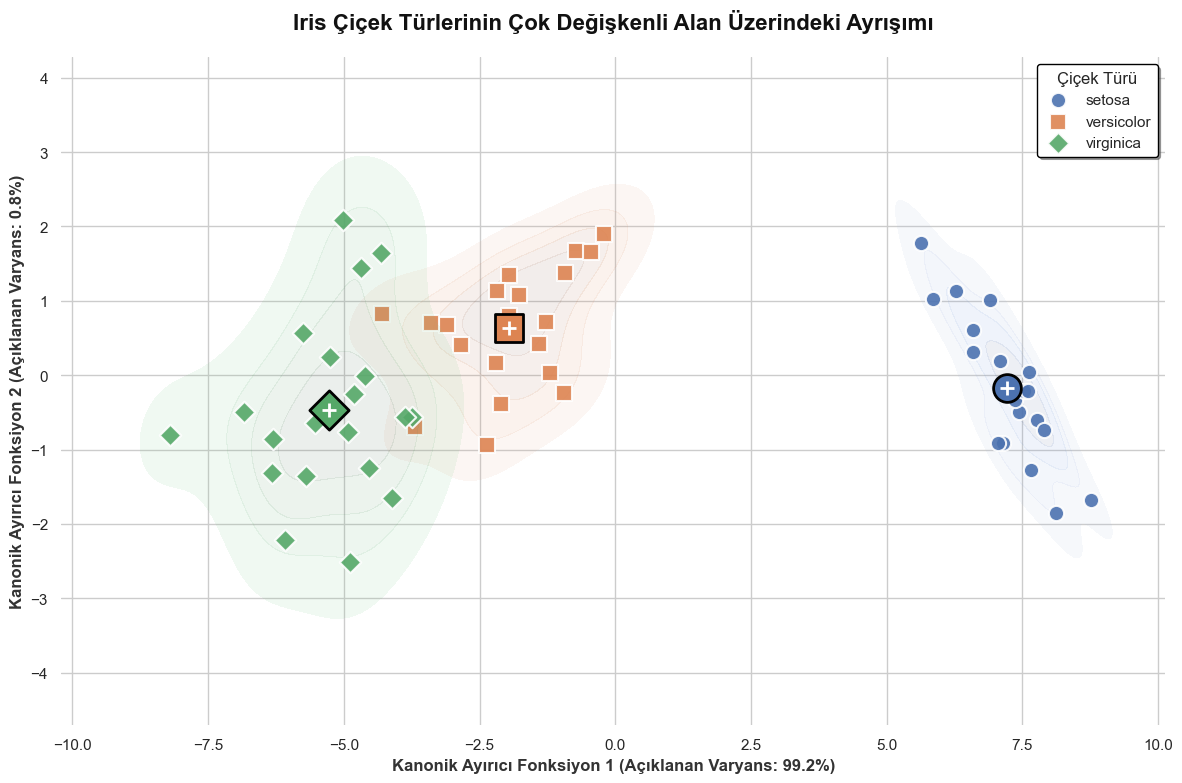

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import pandas as pd
import numpy as np

# --- 1. Veri Hazırlığı ve Model (Zaten yapmıştık, tekrar tanımlayalım) ---
# (df_sample'ın yüklü olduğunu varsayıyorum, eğer değilse iris.groupby... sample(20) kodunu buraya ekle)
X = data[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = data['species']

# LDA Modelini eğitme
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

# Görselleştirme için yeni bir DataFrame oluşturalım
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Species'] = y.values

# --- 2. Profesyonel Görselleştirme ---
# Seaborn temasını kurumsal bir tarzda ayarlayalım
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 8))

# Modern, kurumsal renk paleti ve semboller
colors = ["#4C72B0", "#DD8452", "#55A868"] # Setosa, Versicolor, Virginica için
markers = ["o", "s", "D"] # Daire, Kare, Elmas

# A. Her grup için ayrı ayrı çizim yapalım (Merkezleri ve gölgeleri eklemek için)
for i, species in enumerate(lda_df['Species'].unique()):
    # O türe ait verileri filtrele
    subset = lda_df[lda_df['Species'] == species]
    
    # 1. Hafif Dağılım Gölgesi (Kernel Density Estimate) - Çekicilik katar
    sns.kdeplot(data=subset, x='LD1', y='LD2', color=colors[i], 
                fill=True, alpha=0.1, levels=5, thresh=0.1)
    
    # 2. Asıl Veri Noktaları (Scatter)
    plt.scatter(subset['LD1'], subset['LD2'], 
                color=colors[i], label=species, s=120, 
                edgecolors='white', linewidth=1.5, marker=markers[i], alpha=0.9)
    
    # 3. Grup Merkezini (Centroid) Hesapla ve Vurgula
    centroid_x = subset['LD1'].mean()
    centroid_y = subset['LD2'].mean()
    plt.scatter(centroid_x, centroid_y, color=colors[i], s=400, 
                edgecolors='black', linewidth=2, marker=markers[i], alpha=1)
    # Merkeze küçük bir '+' işareti
    plt.scatter(centroid_x, centroid_y, color='white', s=100, marker='+', linewidth=2)

# B. Eksen Etiketleri ve Tipografi (Kurumsal ve Net)
# Açıklanan Varyans Oranlarını alalım
exp_var = lda_df[['LD1', 'LD2']].var() / lda_df[['LD1', 'LD2']].var().sum()
exp_var_ratio = lda.explained_variance_ratio_ # statsmodels'dan da alınabilir

plt.xlabel(f'Kanonik Ayırıcı Fonksiyon 1 (Açıklanan Varyans: {exp_var_ratio[0]:.1%})', fontsize=12, fontweight='bold', color='#333333')
plt.ylabel(f'Kanonik Ayırıcı Fonksiyon 2 (Açıklanan Varyans: {exp_var_ratio[1]:.1%})', fontsize=12, fontweight='bold', color='#333333')

# C. Başlık (Basit, Net ve Kurumsal)
plt.title('Iris Çiçek Türlerinin Çok Değişkenli Alan Üzerindeki Ayrışımı', fontsize=16, fontweight='bold', pad=20, color='#111111')

# D. Lejant ve Final Dokunuşları
leg = plt.legend(title='Çiçek Türü', fontsize=11, title_fontsize=12, frameon=True, shadow=True)
leg.get_frame().set_edgecolor('black')

plt.tight_layout()
sns.despine(left=True, bottom=True) # Kenar çizgilerini kaldıralım

plt.show()

In [200]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,60.000000,60.000000,60.000000,60.000000
mean,5.840000,3.013333,3.761667,1.191667
std,0.896925,0.392500,1.813891,0.773785
min,4.300000,2.200000,1.100000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.900000,3.000000,4.350000,1.350000
75%,6.400000,3.225000,5.300000,1.825000
max,7.900000,3.800000,6.700000,2.400000


# FACTORIAL MANOVA ANALYSIS - Plant Growth Veri Seti

In [12]:
# Veri Setini Yükleme ve Keşfetme
import pandas as pd
import numpy as np

# PlantGrowth veri setini yükleme
from statsmodels.datasets.co2 import load
# PlantGrowth veri seti için alternatif yol
plant_data = pd.DataFrame({
    'weight': [4.17, 5.58, 5.18, 6.11, 4.50, 4.61, 5.17, 4.56, 5.91, 6.15,
               4.52, 4.23, 4.95, 5.27, 5.77, 3.89, 5.23, 5.05, 4.99, 5.88,
               6.30, 5.37, 5.27, 5.00, 6.15, 4.38, 5.73, 5.45, 5.52, 5.27],
    'group': ['ctrl']*10 + ['trt1']*10 + ['trt2']*10
})

# Faktör 2 ekleyelim (gözlem zamanı)
np.random.seed(42)
plant_growth = plant_data.copy()
plant_growth['time'] = list(['early']*5 + ['late']*5) * 3  # Her grup için 5 early, 5 late

# Daha gerçekçi veri ekleyelim (yükseklik ve kuru ağırlık)
heights = [4.17, 4.50, 5.18, 4.56, 5.91, 4.61, 5.17, 5.58, 4.99, 6.15,
           4.52, 5.27, 4.95, 4.23, 5.77, 3.89, 5.23, 5.05, 5.37, 5.88,
           6.30, 5.45, 5.27, 5.00, 6.15, 4.38, 5.73, 5.52, 5.27, 5.91]

dry_weights = [3.12, 3.45, 3.67, 2.89, 4.12, 2.71, 3.89, 3.56, 3.23, 4.06,
                3.34, 3.89, 3.45, 2.95, 4.23, 2.45, 3.78, 3.56, 3.67, 3.98,
                4.34, 3.78, 3.56, 3.12, 4.01, 2.89, 3.95, 3.78, 3.56, 4.06]

plant_growth['height'] = heights
plant_growth['dry_weight'] = dry_weights

# Veri setini görüntüle
print(plant_growth.head(15))
print("\nVeri Seti Yapısı:")
print(plant_growth.info())
print("\nGrouplara Göre Tanımlayıcı İstatistikler:")
print(plant_growth.groupby('group')[['weight', 'height', 'dry_weight']].describe())

    weight group   time  height  dry_weight
0     4.17  ctrl  early    4.17        3.12
1     5.58  ctrl  early    4.50        3.45
2     5.18  ctrl  early    5.18        3.67
3     6.11  ctrl  early    4.56        2.89
4     4.50  ctrl  early    5.91        4.12
5     4.61  ctrl   late    4.61        2.71
6     5.17  ctrl   late    5.17        3.89
7     4.56  ctrl   late    5.58        3.56
8     5.91  ctrl   late    4.99        3.23
9     6.15  ctrl   late    6.15        4.06
10    4.52  trt1  early    4.52        3.34
11    4.23  trt1  early    5.27        3.89
12    4.95  trt1  early    4.95        3.45
13    5.27  trt1  early    4.23        2.95
14    5.77  trt1  early    5.77        4.23

Veri Seti Yapısı:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   weight      30 non-null     float64
 1   group       30 non-null     object 
 2   time  

In [13]:
# Varsayım Testleri - Çok Değişkenli Normallik (Henze-Zirkler)

# Her faktör kombinasyonu için normallik testi
groups = plant_growth['group'].unique()
times = plant_growth['time'].unique()

print("=" * 70)
print("ÇOK DEĞİŞKENLİ NORMALLİK TESTİ (Henze-Zirkler)")
print("=" * 70)

normality_results_factorial = []

for group in groups:
    for time in times:
        subset = plant_growth[(plant_growth['group'] == group) & 
                              (plant_growth['time'] == time)]
        
        if len(subset) > 2:  # Yeterli veri varsa test et
            test_data = subset[['weight', 'height', 'dry_weight']]
            hz_stat, p_value, normal = pg.multivariate_normality(test_data)
            
            normality_results_factorial.append({
                'Group': group,
                'Time': time,
                'HZ_Stat': hz_stat,
                'p_value': p_value,
                'Normal': 'Evet' if p_value > 0.05 else 'Hayır'
            })
            
            print(f"\n{group.upper()}-{time.upper()}:")
            print(f"  HZ İstatistiği: {hz_stat:.4f}")
            print(f"  p-değeri: {p_value:.4f}")
            print(f"  Normal Dağılım (α=0.05): {'✓ Evet' if p_value > 0.05 else '✗ Hayır'}")

normality_factorial_df = pd.DataFrame(normality_results_factorial)
print("\n" + "=" * 70)
print("ÖZET TABLO:")
print(normality_factorial_df.to_string(index=False))


ÇOK DEĞİŞKENLİ NORMALLİK TESTİ (Henze-Zirkler)

CTRL-EARLY:
  HZ İstatistiği: 0.4302
  p-değeri: 0.4353
  Normal Dağılım (α=0.05): ✓ Evet

CTRL-LATE:
  HZ İstatistiği: 0.4008
  p-değeri: 0.5368
  Normal Dağılım (α=0.05): ✓ Evet

TRT1-EARLY:
  HZ İstatistiği: 0.4044
  p-değeri: 0.5241
  Normal Dağılım (α=0.05): ✓ Evet

TRT1-LATE:
  HZ İstatistiği: 0.5506
  p-değeri: 0.1458
  Normal Dağılım (α=0.05): ✓ Evet

TRT2-EARLY:
  HZ İstatistiği: 0.4037
  p-değeri: 0.5265
  Normal Dağılım (α=0.05): ✓ Evet

TRT2-LATE:
  HZ İstatistiği: 0.5304
  p-değeri: 0.1788
  Normal Dağılım (α=0.05): ✓ Evet

ÖZET TABLO:
Group  Time  HZ_Stat  p_value Normal
 ctrl early 0.430187 0.435296   Evet
 ctrl  late 0.400847 0.536789   Evet
 trt1 early 0.404405 0.524088   Evet
 trt1  late 0.550609 0.145778   Evet
 trt2 early 0.403715 0.526542   Evet
 trt2  late 0.530425 0.178847   Evet


In [14]:
# Box's M Testi - Varyans-Kovaryans Matrislerinin Homojenliği

# Faktorial tasarım için grup kombinasyonu oluştur
plant_growth['group_time'] = plant_growth['group'].str.upper() + '-' + plant_growth['time'].str.upper()

print("\n" + "=" * 70)
print("VARYANS-KOVARYANS MATRİSLERİNİN HOMOJENLİĞİ (Box's M Testi)")
print("=" * 70)

box_m_results_factorial = pg.box_m(
    plant_growth, 
    dvs=['weight', 'height', 'dry_weight'], 
    group='group_time'
)

print("\nBox's M Test Sonuçları:")
print(box_m_results_factorial)
print(f"\nStatistik Değeri: {box_m_results_factorial.iloc[0, 0]:.4f}")
print(f"p-değeri: {box_m_results_factorial.iloc[0, 1]:.4f}")
print(f"Karar (α=0.05): {'✓ Homojen (H₀ Reddedilemez)' if box_m_results_factorial.iloc[0, 1] > 0.05 else '✗ Heterojene (H₀ Reddedilir)'}")



VARYANS-KOVARYANS MATRİSLERİNİN HOMOJENLİĞİ (Box's M Testi)

Box's M Test Sonuçları:
          Chi2    df      pval  equal_cov
box  43.543356  30.0  0.052431       True

Statistik Değeri: 43.5434
p-değeri: 30.0000
Karar (α=0.05): ✓ Homojen (H₀ Reddedilemez)


In [15]:
# Factorial MANOVA - Çok Yönlü MANOVA Analizi

print("\n" + "=" * 70)
print("FACTORIAL MANOVA - ÇOK YÖNLÜ MANOVA ANALİZİ")
print("=" * 70)

# Factorial MANOVA modeli oluştur
# Formula: weight + height + dry_weight ~ group + time + group:time
factorial_manova = MANOVA.from_formula(
    'weight + height + dry_weight ~ C(group) + C(time) + C(group):C(time)',
    data=plant_growth
)

# Sonuçları göster
print("\nWilks' Lambda ve Diğer Test İstatistikleri:")
print(factorial_manova.mv_test())



FACTORIAL MANOVA - ÇOK YÖNLÜ MANOVA ANALİZİ

Wilks' Lambda ve Diğer Test İstatistikleri:
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept         Value  Num DF  Den DF F Value  Pr > F
--------------------------------------------------------------
          Wilks' lambda  0.0572 3.0000 22.0000 120.7899 0.0000
         Pillai's trace  0.9428 3.0000 22.0000 120.7899 0.0000
 Hotelling-Lawley trace 16.4713 3.0000 22.0000 120.7899 0.0000
    Roy's greatest root 16.4713 3.0000 22.0000 120.7899 0.0000
--------------------------------------------------------------
                                                              
--------------------------------------------------------------
          C(group)        Value  Num DF  Den DF F Value Pr > F
--------------------------------------------------------------
            Wilks' lambda 0.6211 6.0000 44.0000

In [7]:
# Univariate ANOVA Analizleri - Her Değişken Ayrı Ayrı

import statsmodels.api as sm
from statsmodels.formula.api import ols

print("\n" + "=" * 70)
print("UNIVARIATE ANOVA ANALİZLERİ")
print("=" * 70)

dependent_vars = ['weight', 'height', 'dry_weight']
variable_names_tr = ['Yaş Ağırlık (weight)', 'Bitki Yüksekliği (height)', 'Kuru Ağırlık (dry_weight)']

# Sonuçları depolamak için liste
univariate_results = []

for var, var_name in zip(dependent_vars, variable_names_tr):
    print(f"\n{var_name.upper()} İçin ANOVA Sonuçları:")
    print("-" * 70)
    
    # Model oluştur: dependent var ~ group + time + group:time
    model = ols(f'{var} ~ C(group) + C(time) + C(group):C(time)', data=plant_growth).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    print(anova_table)
    
    # Sonuçları kaydet
    for idx, row in anova_table.iterrows():
        if idx != 'Residual' and not pd.isna(row['F']):
            univariate_results.append({
                'Dependent Var': var_name,
                'Source': idx,
                'F': row['F'],
                'p': row['PR(>F)'],
                'Significant': 'Evet ✓' if row['PR(>F)'] < 0.05 else 'Hayır'
            })

print("\n" + "=" * 70)
print("ÖZET: TÜM UNIVARIATE ANOVA SONUÇLARI")
print("=" * 70)
univariate_summary_df = pd.DataFrame(univariate_results)
print(univariate_summary_df.to_string(index=False))



UNIVARIATE ANOVA ANALİZLERİ

YAŞ AĞIRLIK (WEIGHT) İçin ANOVA Sonuçları:
----------------------------------------------------------------------
                     sum_sq    df         F    PR(>F)
C(group)           1.087707   2.0  1.235361  0.308564
C(time)            0.011213   1.0  0.025471  0.874534
C(group):C(time)   0.374507   2.0  0.425345  0.658375
Residual          10.565720  24.0       NaN       NaN

BITKI YÜKSEKLIĞI (HEIGHT) İçin ANOVA Sonuçları:
----------------------------------------------------------------------
                    sum_sq    df         F    PR(>F)
C(group)          1.365787   2.0  1.699494  0.204043
C(time)           0.075000   1.0  0.186650  0.669576
C(group):C(time)  0.631440   2.0  0.785722  0.467167
Residual          9.643720  24.0       NaN       NaN

KURU AĞIRLIK (DRY_WEIGHT) İçin ANOVA Sonuçları:
----------------------------------------------------------------------
                    sum_sq    df         F    PR(>F)
C(group)          0.298167  


GÖRSELLEŞTİRME

Görselleştirme başarıyla kaydedildi: factorial_manova_plot.png


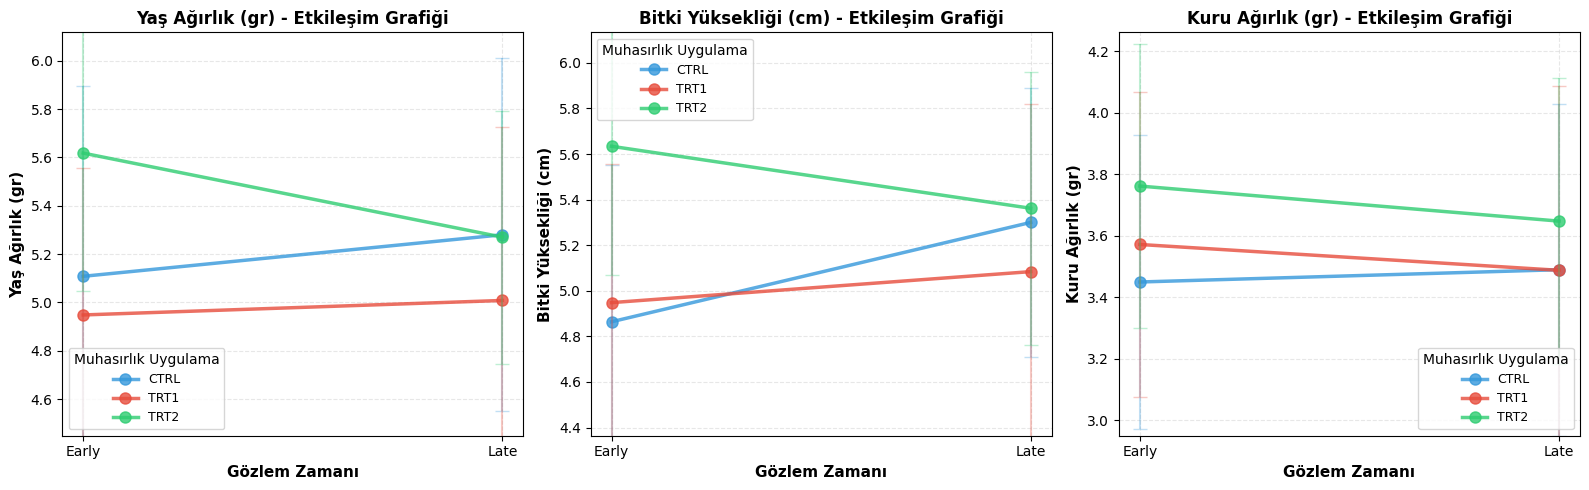

In [8]:
# Görselleştirme - Factorial Tasarım Interaction Plot

import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 70)
print("GÖRSELLEŞTİRME")
print("=" * 70)

# Figür boyutunu ayarla
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

dependent_vars = ['weight', 'height', 'dry_weight']
variable_names_tr = ['Yaş Ağırlık (gr)', 'Bitki Yüksekliği (cm)', 'Kuru Ağırlık (gr)']
colors = {'ctrl': '#3498db', 'trt1': '#e74c3c', 'trt2': '#2ecc71'}

for idx, (var, var_name) in enumerate(zip(dependent_vars, variable_names_tr)):
    ax = axes[idx]
    
    # Her grup ve zaman kombinasyonu için ortalamaları hesapla
    group_means = plant_growth.groupby(['group', 'time'])[var].mean().reset_index()
    group_std = plant_growth.groupby(['group', 'time'])[var].std().reset_index()
    group_means['std'] = group_std[var]
    
    # Etkileşim grafiği çiz
    for group in plant_growth['group'].unique():
        data = group_means[group_means['group'] == group]
        early_val = data[data['time'] == 'early'][var].values[0]
        late_val = data[data['time'] == 'late'][var].values[0]
        early_std = data[data['time'] == 'early']['std'].values[0]
        late_std = data[data['time'] == 'late']['std'].values[0]
        
        # Çizgi çiz
        ax.plot(['Early', 'Late'], [early_val, late_val], 
               marker='o', markersize=8, linewidth=2.5,
               label=group.upper(), color=colors[group], alpha=0.8)
        
        # Error bars ekle
        ax.errorbar(['Early', 'Late'], [early_val, late_val],
                   yerr=[early_std, late_std], fmt='none',
                   color=colors[group], alpha=0.3, linewidth=1.5, capsize=5)
    
    # Eksen ayarları
    ax.set_xlabel('Gözlem Zamanı', fontsize=11, fontweight='bold')
    ax.set_ylabel(var_name, fontsize=11, fontweight='bold')
    ax.set_title(f'{var_name} - Etkileşim Grafiği', fontsize=12, fontweight='bold')
    ax.legend(title='Muhasırlık Uygulama', fontsize=9, title_fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(group_means[var].min() - 0.5, group_means[var].max() + 0.5)

plt.tight_layout()
plt.savefig('c:\\Users\\İlyas\\OneDrive\\Desktop\\çok değişkenli\\factorial_manova_plot.png', dpi=300, bbox_inches='tight')
print("\nGörselleştirme başarıyla kaydedildi: factorial_manova_plot.png")
plt.show()



LDA GÖRSELLEŞTİRMESİ (One-Way MANOVA için)
LDA görselleştirmesi kaydedildi: lda_visualization.png


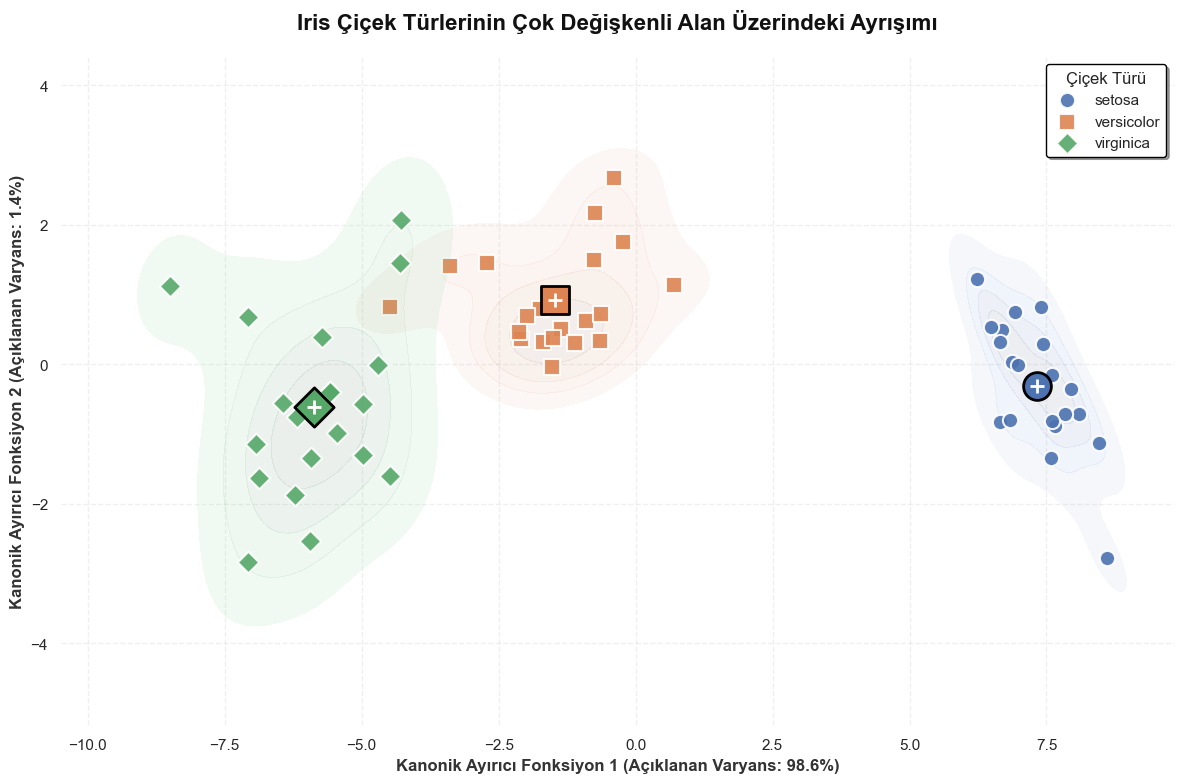

In [13]:
# LDA Görselleştirmesini Kaydet
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Önceki LDA analizinden daha yüksek kaliteli görselleştirme
print("\n" + "=" * 70)
print("LDA GÖRSELLEŞTİRMESİ (One-Way MANOVA için)")
print("=" * 70)

# Iris verisinden 20'şer örnek seç (One-Way MANOVA'da kullanılan veri)
iris_sample = iris.groupby('species').sample(n=20, random_state=42)

# LDA için veri hazırla
X = iris_sample[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = iris_sample['species']

# LDA Modelini eğitme
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)

# Görselleştirme için yeni bir DataFrame oluşturalım
lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Species'] = y.values

# Profesyonel Görselleştirme
sns.set_theme(style="whitegrid", palette="muted")
fig, ax = plt.subplots(figsize=(12, 8))

# Modern, kurumsal renk paleti ve semboller
colors = ["#4C72B0", "#DD8452", "#55A868"] # Setosa, Versicolor, Virginica için
markers = ["o", "s", "D"] # Daire, Kare, Elmas

# Her grup için ayrı ayrı çizim yapalım (Merkezleri ve gölgeleri eklemek için)
for i, species in enumerate(lda_df['Species'].unique()):
    # O türe ait verileri filtrele
    subset = lda_df[lda_df['Species'] == species]
    
    # 1. Hafif Dağılım Gölgesi (Kernel Density Estimate)
    sns.kdeplot(data=subset, x='LD1', y='LD2', color=colors[i], 
                fill=True, alpha=0.1, levels=5, thresh=0.1, ax=ax)
    
    # 2. Asıl Veri Noktaları (Scatter)
    ax.scatter(subset['LD1'], subset['LD2'], 
                color=colors[i], label=species, s=120, 
                edgecolors='white', linewidth=1.5, marker=markers[i], alpha=0.9)
    
    # 3. Grup Merkezini (Centroid) Hesapla ve Vurgula
    centroid_x = subset['LD1'].mean()
    centroid_y = subset['LD2'].mean()
    ax.scatter(centroid_x, centroid_y, color=colors[i], s=400, 
                edgecolors='black', linewidth=2, marker=markers[i], alpha=1)
    # Merkeze küçük bir '+' işareti
    ax.scatter(centroid_x, centroid_y, color='white', s=100, marker='+', linewidth=2)

# Eksen Etiketleri
exp_var_ratio = lda.explained_variance_ratio_

ax.set_xlabel(f'Kanonik Ayırıcı Fonksiyon 1 (Açıklanan Varyans: {exp_var_ratio[0]:.1%})', 
              fontsize=12, fontweight='bold', color='#333333')
ax.set_ylabel(f'Kanonik Ayırıcı Fonksiyon 2 (Açıklanan Varyans: {exp_var_ratio[1]:.1%})', 
              fontsize=12, fontweight='bold', color='#333333')

# Başlık
ax.set_title('Iris Çiçek Türlerinin Çok Değişkenli Alan Üzerindeki Ayrışımı', 
             fontsize=16, fontweight='bold', pad=20, color='#111111')

# Lejant
leg = ax.legend(title='Çiçek Türü', fontsize=11, title_fontsize=12, frameon=True, shadow=True)
leg.get_frame().set_edgecolor('black')

ax.grid(True, alpha=0.3, linestyle='--')
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('c:\\Users\\İlyas\\OneDrive\\Desktop\\çok değişkenli\\lda_visualization.png', dpi=300, bbox_inches='tight')
print("LDA görselleştirmesi kaydedildi: lda_visualization.png")
plt.show()
